<a href="https://colab.research.google.com/github/santiagom27/Parcial2/blob/main/Parcial2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

**Autor:** Juan Santiago Méndez  
**Profesor:** John Corredor  
**Fecha de Inicio:** 13/04/2026  
**Fecha de Entrega:** 28/04/2026  


## **Problemática**

El tratamiento del agua es indispensable para garantizar su pureza y calidad para el consumo humano y la preservación de ecosistemas acuáticos. Uno de los elementos significativos es aplicar los conceptos del Procesamiento de Datos en Alto Volumen para diagnosticar la calidad del agua. El presente trabajo aplica metodologías de PAVD para analizar y predecir la calidad del agua en ríos de la **India**.

## **Objetivo**

Implementar y comparar modelos de predicción utilizando (1) **Regresión Lineal con MLlib de PySpark** y (2) **Red Neuronal Densa con Keras/TensorFlow**, con el fin de predecir el Índice de Calidad del Agua (WQI) y evaluar su desempeño mediante métricas cuantitativas.

## **Metodología**

1. Importación de datos (CSV local)
2. Preprocesamiento: limpieza de nulos, transformación de tipos, EDA y estadísticas descriptivas
3. Cálculo del Índice de Calidad del Agua (WQI) según referencia bibliográfica
4. Modelo 1: **Regresión Lineal (MLlib PySpark)**
5. Modelo 2: **Red Neuronal Densa (Keras Sequential)**
6. Evaluación comparativa: R², MAE, RMSE, MSE
7. Conclusiones

> **Referencia:** Calidad de parámetros del agua: https://www.intechopen.com/chapters/69568


## **1. Importación de Bibliotecas**


In [59]:
# ⚠️ PASO 1: Ejecuta SOLO esta celda primero, luego ve a
# Entorno de ejecución → Reiniciar sesión → y continúa con el resto
import subprocess, sys
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'pyspark', 'findspark', 'geopandas',
    'adjustText', 'mapclassify'
], check=True)
print('✅ Instalación completa. Ahora reinicia el runtime y ejecuta el resto.')


✅ Instalación completa. Ahora reinicia el runtime y ejecuta el resto.


In [60]:
# ⚠️ PASO 2: Ejecuta desde aquí en adelante (después de reiniciar)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pylab import *

import findspark
findspark.init()

import pyspark.sql.functions as F
from pyspark import SparkConf
from pyspark.sql import SQLContext, SparkSession
from pyspark.sql.types import *

# MLlib
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Keras / TensorFlow
import keras
from keras.models import Sequential
from keras.layers import Dense

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print('✅ Bibliotecas importadas correctamente.')


✅ Bibliotecas importadas correctamente.


## **2. Levantamiento de Sesión Spark**


In [61]:
configura = SparkConf()
configura.setAppName('Calidad_Agua_Mendez')

sparkS = SparkSession.builder.config(conf=configura).getOrCreate()
SQLContext(sparkContext=sparkS.sparkContext, sparkSession=sparkS)
sparkContextoS = sparkS.sparkContext.getOrCreate()

print('Sesión Spark creada: Calidad_Agua_Mendez')
sparkS


Sesión Spark creada: Calidad_Agua_Mendez


## **3. Carga de Datos**

El dataset `waterquality.csv` contiene mediciones fisicoquímicas y bacteriológicas de ríos en distintos estados de la India, obtenidos del programa oficial de monitoreo hídrico (RiverIndia). Cada registro representa el promedio de un período de medición en una estación específica.


In [62]:

df00 = sparkS.read.format('csv').option('header', 'true').load('waterquality.csv')

print(f'Registros cargados: {df00.count()}')
print(f'Columnas: {df00.columns}')
df00.show(5)


Registros cargados: 534
Columnas: ['STATION CODE', 'LOCATIONS', 'STATE', 'TEMP', 'DO', 'pH', 'CONDUCTIVITY', 'BOD', 'NITRATE_N_NITRITE_N', 'FECAL_COLIFORM', 'TOTAL_COLIFORM']
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7

## **4. Análisis y Preparación de Datos**

### Descripción de columnas

| Columna | Descripción | Unidad |
|---|---|---|
| `STATION CODE` | Código de estación de medida | — |
| `LOCATIONS` | Ubicación del río/estación | — |
| `STATE` | Estado de la India | — |
| `TEMP` | Temperatura del agua | °C |
| `DO` | Oxígeno Disuelto — mayor valor = mejor calidad | mg/L |
| `pH` | Nivel ácido/básico (óptimo: 7.0–8.5) | adimensional |
| `CONDUCTIVITY` | Capacidad de conducción eléctrica — agua pura no conduce | µS/cm |
| `BOD` | Demanda Bioquímica de O₂ — mayor BOD = mayor contaminación orgánica | mg/L |
| `NITRATE_N_NITRITE_N` | Nitratos/Nitritos — concentraciones altas degradan calidad | mg/L |
| `FECAL_COLIFORM` | Coliformes fecales — indicador directo de contaminación | UFC/100mL |
| `TOTAL_COLIFORM` | *Se elimina — no aporta al cálculo WQI* | — |


In [63]:
# Estadísticas descriptivas por columna
for col in df00.columns:
    df00.describe([col]).show()


+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+

+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+---------

### **4.1 Visualización de Datos Nulos**


In [64]:
# Verificación de nulos — solo isNull (todo es StringType antes del cast)
df00.select([
    F.count(F.when(F.col(c).isNull() | (F.col(c) == ""), c)).alias(c)
    for c in df00.columns
]).show()


+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



### **4.2 Filtrado y transformación de tipos**


In [65]:
from pyspark.sql.types import StringType

df01.select([
    F.count(F.when(
        F.col(c).isNull() | (F.col(c).cast(StringType()) == ""), c
    )).alias(c)
    for c in df01.columns
]).show()

print(f'Registros después del filtrado: {df01.count()}')


+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+

Registros después del filtrado: 447


## **5. Análisis Exploratorio — Visualización de Parámetros**

Se grafican los parámetros físico-químicos a lo largo de todas las observaciones del dataset para identificar distribuciones, outliers y comportamientos generales.


In [66]:
df01.createOrReplaceTempView('df01_sql')

do_parametro   = sparkS.sql('SELECT DO FROM df01_sql').rdd.map(lambda r: r.DO).collect()
ph_parametro   = sparkS.sql('SELECT pH FROM df01_sql').rdd.map(lambda r: r.pH).collect()
BOD_parametro  = sparkS.sql('SELECT BOD FROM df01_sql').rdd.map(lambda r: r.BOD).collect()
NN_parametro   = sparkS.sql('SELECT NITRATE_N_NITRITE_N FROM df01_sql').rdd.map(lambda r: r.NITRATE_N_NITRITE_N).collect()
COND_parametro = sparkS.sql('SELECT CONDUCTIVITY FROM df01_sql').rdd.map(lambda r: r.CONDUCTIVITY).collect()
FC_parametro   = sparkS.sql('SELECT FECAL_COLIFORM FROM df01_sql').rdd.map(lambda r: r.FECAL_COLIFORM).collect()

print(f'Total de observaciones: {len(do_parametro)}')

Total de observaciones: 447


In [67]:
# Reemplazar 'NA' (y variantes) por NULL antes del cast
cols_numericas = ['TEMP', 'pH', 'DO', 'CONDUCTIVITY', 'NITRATE_N_NITRITE_N', 'FECAL_COLIFORM', 'BOD']

df01 = df00.drop('TOTAL_COLIFORM')

for c in cols_numericas:
    # Convertir 'NA', 'na', 'N/A', '' a NULL, luego castear a FloatType
    df01 = df01.withColumn(c,
        F.when(F.upper(F.col(c)).isin(['NA', 'N/A', 'NULL', 'NONE', '']), None)
         .otherwise(F.col(c))
         .cast(FloatType())
    )

# Eliminar filas que quedaron con NULL en cualquier columna numérica
df01 = df01.dropna(subset=cols_numericas)

print(f'Registros tras limpiar NAs: {df01.count()}')
df01.show(5)


Registros tras limpiar NAs: 447
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0|4.2|                9.0|          59.0|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0|5.6|               3.55|          90.0|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|       294.0|3.2|               2.69|          45.0|
+------------+--------------------+-----------+----+---+---+----

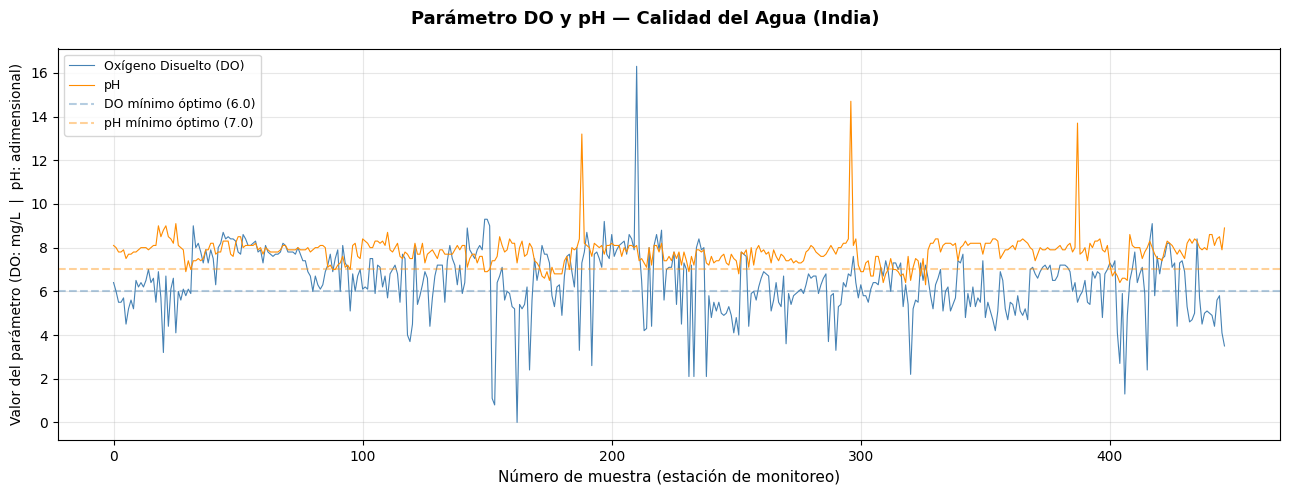

In [68]:
# ── Gráfica 1: Oxígeno Disuelto vs pH ──
tam = len(do_parametro)
fig, ax1 = plt.subplots(figsize=(13, 5), facecolor='w')
ax1.plot(range(tam), do_parametro, label='Oxígeno Disuelto (DO)', color='steelblue', linewidth=0.8)
ax1.plot(range(tam), ph_parametro, label='pH', color='darkorange', linewidth=0.8)
fig.suptitle('Parámetro DO y pH — Calidad del Agua (India)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Número de muestra (estación de monitoreo)', fontsize=11)
ax1.set_ylabel('Valor del parámetro (DO: mg/L  |  pH: adimensional)', fontsize=10)
ax1.axhline(y=6.0, color='steelblue', linestyle='--', alpha=0.4, label='DO mínimo óptimo (6.0)')
ax1.axhline(y=7.0, color='darkorange', linestyle='--', alpha=0.4, label='pH mínimo óptimo (7.0)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


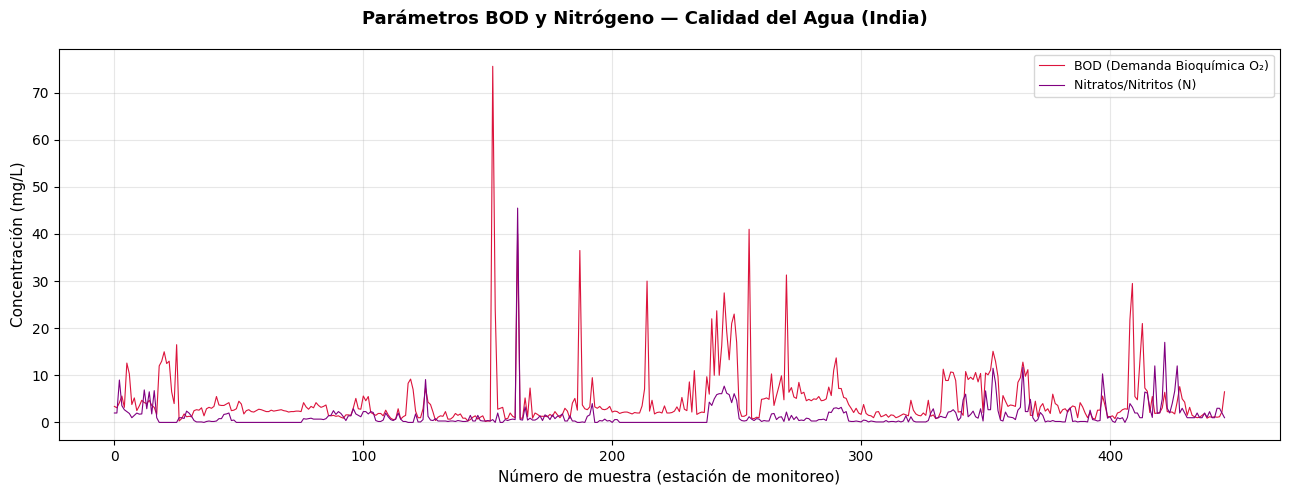

In [69]:
# ── Gráfica 2: BOD vs Nitratos/Nitritos ──
fig, ax1 = plt.subplots(figsize=(13, 5), facecolor='w')
ax1.plot(range(tam), BOD_parametro, label='BOD (Demanda Bioquímica O₂)', color='crimson', linewidth=0.8)
ax1.plot(range(tam), NN_parametro, label='Nitratos/Nitritos (N)', color='purple', linewidth=0.8)
fig.suptitle('Parámetros BOD y Nitrógeno — Calidad del Agua (India)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Número de muestra (estación de monitoreo)', fontsize=11)
ax1.set_ylabel('Concentración (mg/L)', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


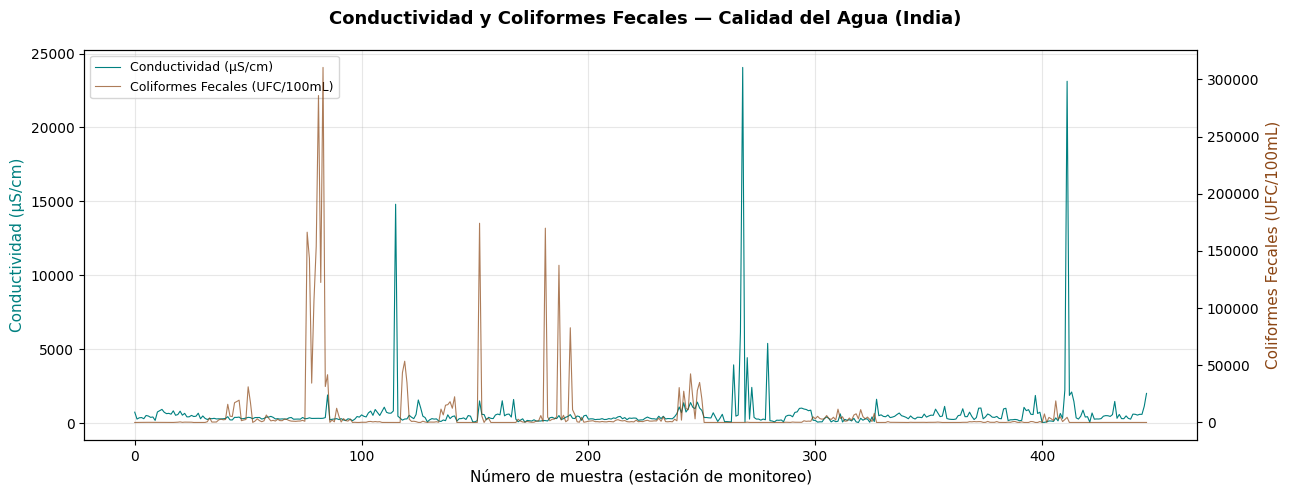

In [70]:
# ── Gráfica 3: Conductividad vs Coliformes Fecales ──
fig, ax1 = plt.subplots(figsize=(13, 5), facecolor='w')
ax1.plot(range(tam), COND_parametro, label='Conductividad (µS/cm)', color='teal', linewidth=0.8)
ax2 = ax1.twinx()
ax2.plot(range(tam), FC_parametro, label='Coliformes Fecales (UFC/100mL)', color='saddlebrown', linewidth=0.8, alpha=0.7)
fig.suptitle('Conductividad y Coliformes Fecales — Calidad del Agua (India)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Número de muestra (estación de monitoreo)', fontsize=11)
ax1.set_ylabel('Conductividad (µS/cm)', fontsize=11, color='teal')
ax2.set_ylabel('Coliformes Fecales (UFC/100mL)', fontsize=11, color='saddlebrown')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## **6. Cálculo del Índice de Calidad del Agua (WQI)**

### 6.1 Rangos de calidad por parámetro (qr)

Para cada variable se asigna un rango de calidad discreto según umbrales bibliográficos:
- **100** = condición excelente para ese parámetro
- **80** = buena
- **60** = moderada
- **40** = baja
- **0** = inadecuada

### 6.2 Pesos ponderados

| Parámetro | Peso (w) |
|---|---|
| DO (Oxígeno Disuelto) | 0.281 |
| FECAL_COLIFORM | 0.281 |
| CONDUCTIVITY | 0.234 |
| pH | 0.165 |
| NITRATE_N_NITRITE_N | 0.028 |
| BOD | 0.009 |

**WQI = Σ(qrᵢ × wᵢ)**


In [71]:
# ── Rangos de calidad por parámetro ──

# qrPH: pH óptimo 7.0 – 8.5
df02 = df01.withColumn('qrPH',
    F.when((df01.pH >= 7) & (df01.pH <= 8.5), 100)
     .when(((df01.pH >= 6.8) & (df01.pH < 6.9)) | ((df01.pH > 8.5) & (df01.pH < 8.6)), 80)
     .when(((df01.pH >= 6.7) & (df01.pH < 6.8)) | ((df01.pH >= 8.6) & (df01.pH < 8.8)), 60)
     .when(((df01.pH >= 6.5) & (df01.pH < 6.7)) | ((df01.pH >= 8.8) & (df01.pH < 9.0)), 40)
     .otherwise(0)
)

# qrDO: DO >= 6.0 es óptimo
df02 = df02.withColumn('qrDO',
    F.when(df01.DO >= 6.0, 100)
     .when((df01.DO >= 5.1) & (df01.DO < 6.0), 80)
     .when((df01.DO >= 4.1) & (df01.DO < 5.0), 60)
     .when((df01.DO >= 3.0) & (df01.DO <= 4.0), 40)
     .otherwise(0)
)

# qrCOND: Conductividad baja = mejor
df02 = df02.withColumn('qrCOND',
    F.when((df01.CONDUCTIVITY >= 0.0) & (df01.CONDUCTIVITY <= 75.0), 100)
     .when((df01.CONDUCTIVITY > 75.0) & (df01.CONDUCTIVITY <= 150.0), 80)
     .when((df01.CONDUCTIVITY > 150.0) & (df01.CONDUCTIVITY <= 225.0), 60)
     .when((df01.CONDUCTIVITY > 225.0) & (df01.CONDUCTIVITY <= 300.0), 40)
     .otherwise(0)
)

# qrBOD: BOD bajo = mejor
df02 = df02.withColumn('qrBOD',
    F.when((df01.BOD >= 0.0) & (df01.BOD < 3.0), 100)
     .when((df01.BOD >= 3.0) & (df01.BOD < 6.0), 80)
     .when((df01.BOD >= 6.0) & (df01.BOD < 80.0), 60)
     .when((df01.BOD >= 80.0) & (df01.BOD < 125.0), 40)
     .otherwise(0)
)

# qrNN: Nitratos/Nitritos
df02 = df02.withColumn('qrNN',
    F.when((df01.NITRATE_N_NITRITE_N >= 0.0) & (df01.NITRATE_N_NITRITE_N < 20.0), 100)
     .when((df01.NITRATE_N_NITRITE_N >= 20.0) & (df01.NITRATE_N_NITRITE_N < 50.0), 80)
     .when((df01.NITRATE_N_NITRITE_N >= 50.0) & (df01.NITRATE_N_NITRITE_N < 100.0), 60)
     .when((df01.NITRATE_N_NITRITE_N >= 100.0) & (df01.NITRATE_N_NITRITE_N < 200.0), 40)
     .otherwise(0)
)

# qrFecal: Coliformes fecales
df02 = df02.withColumn('qrFecal',
    F.when((df01.FECAL_COLIFORM >= 0.0) & (df01.FECAL_COLIFORM < 5.0), 100)
     .when((df01.FECAL_COLIFORM >= 5.0) & (df01.FECAL_COLIFORM < 50.0), 80)
     .when((df01.FECAL_COLIFORM >= 50.0) & (df01.FECAL_COLIFORM < 500.0), 60)
     .when((df01.FECAL_COLIFORM >= 500.0) & (df01.FECAL_COLIFORM < 1000.0), 40)
     .otherwise(0)
)

print('Rangos de calidad calculados:')
df02.show(10)


Rangos de calidad calculados:
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371

In [72]:
# ── Índices ponderados y WQI ──
df03 = df02.withColumn('wpH',   F.round(df02.qrPH   * 0.165, 3))
df03 = df03.withColumn('wDO',   F.round(df03.qrDO   * 0.281, 3))
df03 = df03.withColumn('wCOND', F.round(df03.qrCOND * 0.234, 3))
df03 = df03.withColumn('wBOD',  F.round(df03.qrBOD  * 0.009, 3))
df03 = df03.withColumn('wNN',   F.round(df03.qrNN   * 0.028, 3))
df03 = df03.withColumn('wFecal',F.round(df03.qrFecal* 0.281, 3))

# WQI = suma de ponderaciones
df04 = df03.withColumn('WQI',
    F.round(df03.wpH + df03.wBOD + df03.wCOND + df03.wNN + df03.wFecal + df03.wDO, 3)
)

print('WQI calculado:')
df04.select('STATE', 'WQI').show(10)


WQI calculado:
+-----------+-----+
|      STATE|  WQI|
+-----------+-----+
|MAHARASHTRA|76.22|
|MAHARASHTRA|74.34|
|MAHARASHTRA|59.36|
|MAHARASHTRA|59.36|
|MAHARASHTRA|74.34|
|MAHARASHTRA|53.56|
|MAHARASHTRA|59.18|
|MAHARASHTRA|59.36|
|MAHARASHTRA|59.36|
|MAHARASHTRA|84.82|
+-----------+-----+
only showing top 10 rows


In [73]:
# ── Etiqueta CALIDAD ──
# Excelente [0,25) | Buena [25,50) | Baja [50,75) | Muy_Baja [75,100) | Inadecuada >=100
df05 = df04.withColumn('CALIDAD',
    F.when((df04.WQI >= 0)  & (df04.WQI < 25),  'Excelente')
     .when((df04.WQI >= 25) & (df04.WQI < 50),  'Buena')
     .when((df04.WQI >= 50) & (df04.WQI < 75),  'Baja')
     .when((df04.WQI >= 75) & (df04.WQI < 100), 'Muy_Baja')
     .otherwise('Inadecuada')
)

print('Distribución de categorías de calidad:')
df05.groupBy('CALIDAD').count().orderBy('count', ascending=False).show()


Distribución de categorías de calidad:
+---------+-----+
|  CALIDAD|count|
+---------+-----+
|     Baja|  261|
|    Buena|  104|
| Muy_Baja|   68|
|Excelente|   14|
+---------+-----+



## **7. Visualización Geográfica — Mapa WQI de la India**

Se integra la información del WQI promedio por estado con los shapefiles geográficos de los estados de la India.


In [74]:
import geopandas as gpd
from adjustText import adjust_text

# Normalización de nombres de estados (armonización shapefile ↔ dataset)
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))
df06 = df06.withColumn('STATE', F.initcap('STATE'))
df06.show(5)


+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2182|G

In [75]:
# Cargar shapefile (la carpeta Indian_States/ debe estar en el mismo directorio)
rutaMapas = 'Indian_States/Indian_States.shx'
gpd01 = gpd.read_file(rutaMapas)

# Armonizar nombres en shapefile
gpd02 = gpd01.replace({
    'Andaman & Nicobar Island': 'Andaman Nicobar Island',
    'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
    'Daman & Diu': 'Daman Diu',
    'Jammu & Kashmir': 'Jammu Kashmir',
    'NCT of Delhi': 'Delhi'
})
gpd03 = gpd02.rename(columns={'st_nm': 'STATE'})

# Merge outer: mapa + datos Spark
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [c[0] for c in dfMAP['coords']]
dfMAP = dfMAP.drop_duplicates(subset='STATE')

# Imputar WQI nulos con la mediana (estados sin datos en el CSV)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

print(f'Estados en el mapa: {len(dfMAP)}')


Estados en el mapa: 36


In [76]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


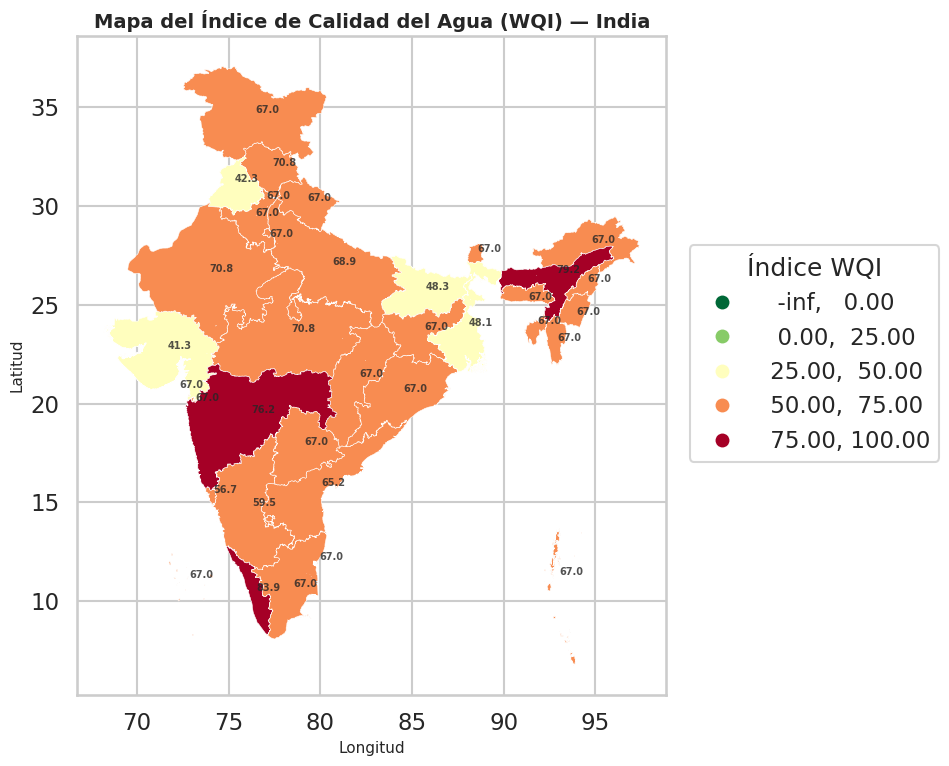

In [77]:
# ── Mapa WQI con clasificación por intervalos ──
sns.set_context('talk')
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(12, 8))
dfMAP.plot(
    column='WQI', cmap='RdYlGn_r', ax=ax,
    scheme='userdefined', classification_kwds={'bins': [0, 25, 50, 75, 100]},
    legend=True, linewidth=0.4, edgecolor='white'
)

leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1.02, 0.7))

# Etiquetas de WQI en cada estado
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        t = ax.annotate(f"{row['WQI']:.1f}", xy=(centroide.x, centroide.y),
                        fontsize=7, alpha=0.8, fontweight='bold')
        textos.append(t)
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

ax.set_title('Mapa del Índice de Calidad del Agua (WQI) — India', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitud', fontsize=11)
ax.set_ylabel('Latitud', fontsize=11)
plt.tight_layout()
plt.show()


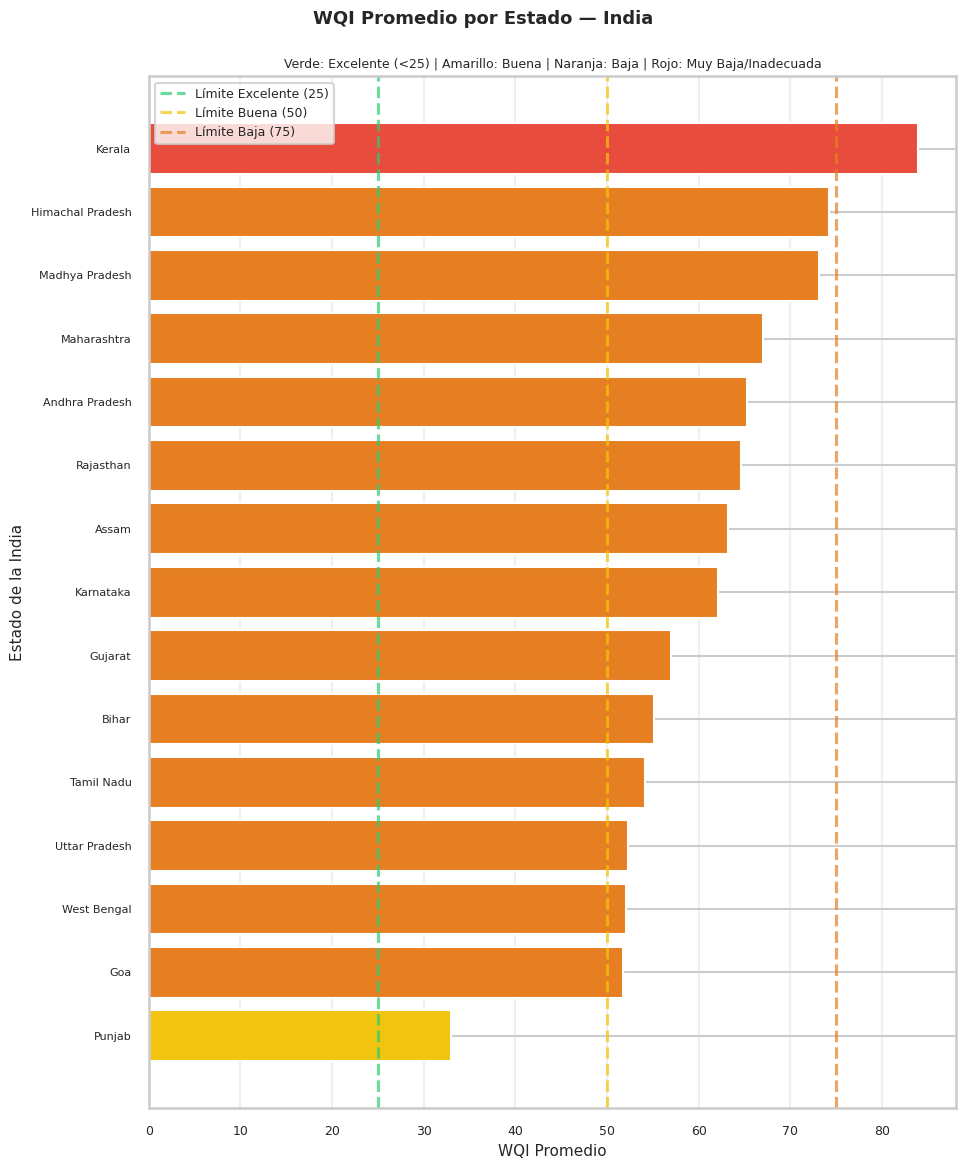

In [78]:
# ── Histograma WQI por Estado ──
df06.createOrReplaceTempView('df06_sql')

# Promedio WQI por estado
df_estados = sparkS.sql('SELECT STATE, AVG(WQI) as WQI_prom FROM df06_sql GROUP BY STATE ORDER BY WQI_prom')
estados_list = df_estados.rdd.map(lambda r: r.STATE).collect()
wqi_list     = df_estados.rdd.map(lambda r: float(r.WQI_prom)).collect()

colors = ['#2ecc71' if w < 25 else '#f1c40f' if w < 50 else '#e67e22' if w < 75 else '#e74c3c'
          for w in wqi_list]

plt.figure(figsize=(10, 12))
bars = plt.barh(estados_list, wqi_list, color=colors, edgecolor='white')
plt.axvline(x=25, color='#2ecc71', linestyle='--', alpha=0.7, label='Límite Excelente (25)')
plt.axvline(x=50, color='#f1c40f', linestyle='--', alpha=0.7, label='Límite Buena (50)')
plt.axvline(x=75, color='#e67e22', linestyle='--', alpha=0.7, label='Límite Baja (75)')
plt.suptitle('WQI Promedio por Estado — India', fontsize=13, fontweight='bold')
plt.title('Verde: Excelente (<25) | Amarillo: Buena | Naranja: Baja | Rojo: Muy Baja/Inadecuada', fontsize=9)
plt.xlabel('WQI Promedio', fontsize=11)
plt.ylabel('Estado de la India', fontsize=11)
plt.xticks(fontsize=9)
plt.yticks(fontsize=8)
plt.legend(fontsize=9)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## **8. Preparación de Datos para Modelos ML**

Las features de entrada son los 6 rangos de calidad individuales (`qrPH`, `qrDO`, `qrCOND`, `qrBOD`, `qrNN`, `qrFecal`) y la variable objetivo es `WQI` (valor continuo → problema de **regresión**).


In [79]:
# Seleccionar features y target
feature_cols = ['qrPH', 'qrDO', 'qrCOND', 'qrBOD', 'qrNN', 'qrFecal']
target_col   = 'WQI'

dfcalidad  = df06.select(*feature_cols)
dfPredecir = df06.select(target_col)

print(f'Dataset completo: {df06.count()} registros, {len(feature_cols)} features')
dfcalidad.show(5)
dfPredecir.show(5)


Dataset completo: 447 registros, 6 features
+----+----+------+-----+----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+----+------+-----+----+-------+
| 100| 100|     0|   80| 100|    100|
| 100| 100|    40|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|    40|   80| 100|     80|
+----+----+------+-----+----+-------+
only showing top 5 rows
+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows


In [80]:
# Split 80/20 — mismo para ambos modelos (reproducibilidad)
from sklearn.model_selection import train_test_split

X = dfcalidad.toPandas()
y = dfPredecir.toPandas()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Entrenamiento : {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Prueba        : {X_test.shape[0]}  registros ({X_test.shape[0]/len(X)*100:.1f}%)')


Entrenamiento : 357 registros (79.9%)
Prueba        : 90  registros (20.1%)


## **9. Modelo 1 — Regresión Lineal (MLlib PySpark)**

PySpark MLlib requiere que las features estén en un único vector (`features`). Se usa `VectorAssembler` para transformar las columnas individuales en el formato requerido.


In [81]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Preparar dataset Spark con VectorAssembler
df_ml = df06.select(*feature_cols, target_col).dropna()

# Asegurar que todos los campos sean numéricos
for col_name in feature_cols:
    df_ml = df_ml.withColumn(col_name, df_ml[col_name].cast(FloatType()))
df_ml = df_ml.withColumn('WQI', df_ml['WQI'].cast(FloatType()))

assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')
df_assembled = assembler.transform(df_ml).select('features', 'WQI')

# Split Spark (mismo random_state para comparabilidad)
df_train_sp, df_test_sp = df_assembled.randomSplit([0.8, 0.2], seed=42)

print(f'Train Spark: {df_train_sp.count()} | Test Spark: {df_test_sp.count()}')


Train Spark: 383 | Test Spark: 64


In [82]:
# ── Entrenar modelo de Regresión Lineal ──
lr = LinearRegression(
    featuresCol='features',
    labelCol='WQI',
    maxIter=200,
    regParam=0.01,      # Regularización L2 (Ridge)
    elasticNetParam=0.0 # 0.0 = Ridge puro
)

lr_model = lr.fit(df_train_sp)

print('Modelo MLlib entrenado.')
print(f'Coeficientes: {lr_model.coefficients}')
print(f'Intercepto  : {lr_model.intercept:.4f}')


Modelo MLlib entrenado.
Coeficientes: [0.16484733052704673,0.2808015832877609,0.23373332003585232,0.009239945804160214,0.0,0.2807665883102122]
Intercepto  : 2.8265


In [83]:
# ── Predicciones y métricas MLlib ──
pred_train_sp = lr_model.transform(df_train_sp)
pred_test_sp  = lr_model.transform(df_test_sp)

evaluator_rmse = RegressionEvaluator(labelCol='WQI', predictionCol='prediction', metricName='rmse')
evaluator_mae  = RegressionEvaluator(labelCol='WQI', predictionCol='prediction', metricName='mae')
evaluator_r2   = RegressionEvaluator(labelCol='WQI', predictionCol='prediction', metricName='r2')

rmse_train_lr = evaluator_rmse.evaluate(pred_train_sp)
rmse_test_lr  = evaluator_rmse.evaluate(pred_test_sp)
mae_test_lr   = evaluator_mae.evaluate(pred_test_sp)
r2_test_lr    = evaluator_r2.evaluate(pred_test_sp)
mse_test_lr   = rmse_test_lr ** 2

print('='*45)
print('  MÉTRICAS — Regresión Lineal (MLlib)')
print('='*45)
print(f'  RMSE Entrenamiento : {rmse_train_lr:.4f}')
print(f'  RMSE Prueba        : {rmse_test_lr:.4f}')
print(f'  MAE  Prueba        : {mae_test_lr:.4f}')
print(f'  MSE  Prueba        : {mse_test_lr:.4f}')
print(f'  R²   Prueba        : {r2_test_lr:.4f}')
print('='*45)


  MÉTRICAS — Regresión Lineal (MLlib)
  RMSE Entrenamiento : 0.0116
  RMSE Prueba        : 0.0724
  MAE  Prueba        : 0.0203
  MSE  Prueba        : 0.0052
  R²   Prueba        : 1.0000


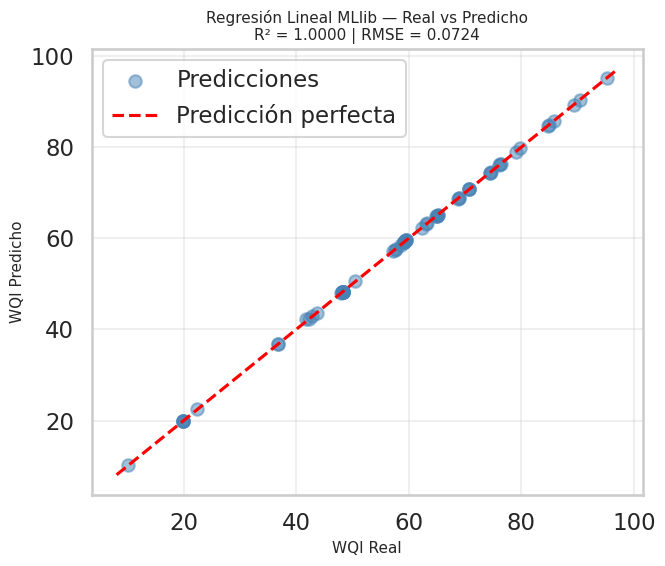

In [84]:
# ── Gráfica: Valores reales vs predichos (MLlib) ──
pred_pd = pred_test_sp.select('WQI', 'prediction').toPandas()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pred_pd['WQI'], pred_pd['prediction'], alpha=0.5, color='steelblue', label='Predicciones')
lims = [min(pred_pd['WQI'].min(), pred_pd['prediction'].min()) - 2,
        max(pred_pd['WQI'].max(), pred_pd['prediction'].max()) + 2]
ax.plot(lims, lims, 'r--', label='Predicción perfecta')
ax.set_xlabel('WQI Real', fontsize=11)
ax.set_ylabel('WQI Predicho', fontsize=11)
ax.set_title(f'Regresión Lineal MLlib — Real vs Predicho\nR² = {r2_test_lr:.4f} | RMSE = {rmse_test_lr:.4f}', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## **10. Modelo 2 — Red Neuronal Densa (Keras)**

Se implementa una red neuronal MLP (Multi-Layer Perceptron) con 3 capas ocultas de activación ReLU y una capa de salida lineal, apropiada para regresión continua.

| Capa | Tipo | Neuronas | Activación |
|---|---|---|---|
| Entrada + Dense 1 | Dense | 350 | ReLU |
| Dense 2 | Dense | 350 | ReLU |
| Dense 3 | Dense | 350 | ReLU |
| Salida | Dense | 1 | Linear |


In [85]:
import keras
from keras.models import Sequential
from keras.layers import Dense

# Hiperparámetros
EPOCAS   = 200
LOTE     = 32
LR       = 0.001

# Arquitectura
modelo01 = Sequential([
    Dense(350, input_dim=6, activation='relu'),
    Dense(350, activation='relu'),
    Dense(350, activation='relu'),
    Dense(1,   activation='linear')
])

# Compilación con Adam y MSE
modelo01.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='mean_squared_error',
    metrics=['mse']
)

modelo01.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
# ── Entrenamiento ──
historial = modelo01.fit(
    X_train, y_train,
    epochs=EPOCAS,
    batch_size=LOTE,
    validation_split=0.1,  # 10% de entrenamiento como validación interna
    verbose=0
)

print('Entrenamiento finalizado.')
print(f'MSE final (entrenamiento) : {historial.history["mse"][-1]:.4f}')
print(f'MSE final (validación)    : {historial.history["val_mse"][-1]:.4f}')


Entrenamiento finalizado.
MSE final (entrenamiento) : 0.0930
MSE final (validación)    : 0.0541


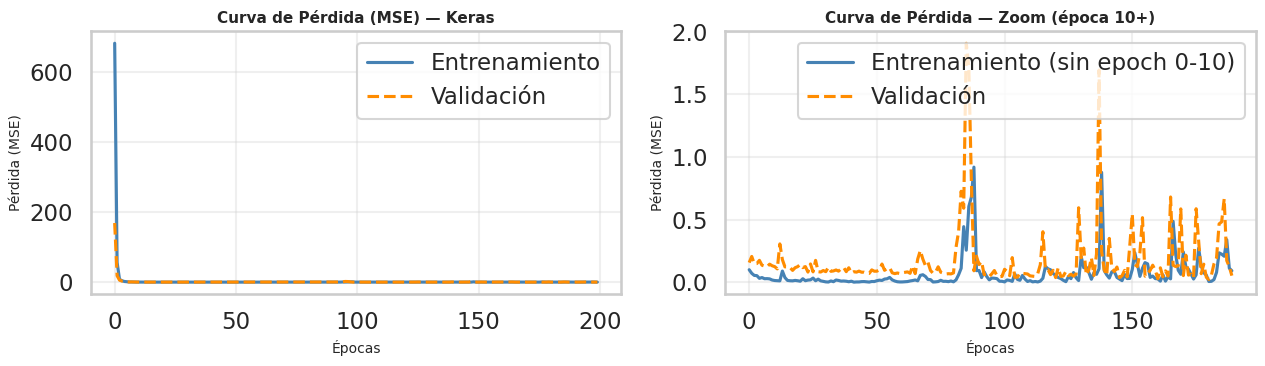

In [87]:
# ── Curva de pérdida ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(historial.history['loss'], color='steelblue', label='Entrenamiento')
axes[0].plot(historial.history['val_loss'], color='darkorange', linestyle='--', label='Validación')
axes[0].set_title('Curva de Pérdida (MSE) — Keras', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Épocas', fontsize=10)
axes[0].set_ylabel('Pérdida (MSE)', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historial.history['loss'][10:], color='steelblue', label='Entrenamiento (sin epoch 0-10)')
axes[1].plot(historial.history['val_loss'][10:], color='darkorange', linestyle='--', label='Validación')
axes[1].set_title('Curva de Pérdida — Zoom (época 10+)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Épocas', fontsize=10)
axes[1].set_ylabel('Pérdida (MSE)', fontsize=10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [88]:
# ── Métricas Keras ──
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred_train_k = modelo01.predict(X_train).flatten()
y_pred_test_k  = modelo01.predict(X_test).flatten()

y_train_flat = y_train.values.flatten()
y_test_flat  = y_test.values.flatten()

r2_train_k   = r2_score(y_train_flat, y_pred_train_k)
r2_test_k    = r2_score(y_test_flat,  y_pred_test_k)
mae_test_k   = mean_absolute_error(y_test_flat, y_pred_test_k)
mse_test_k   = mean_squared_error(y_test_flat,  y_pred_test_k)
rmse_test_k  = np.sqrt(mse_test_k)

print('='*45)
print('  MÉTRICAS — Red Neuronal Keras')
print('='*45)
print(f'  R²   Entrenamiento : {r2_train_k:.4f}')
print(f'  R²   Prueba        : {r2_test_k:.4f}')
print(f'  MAE  Prueba        : {mae_test_k:.4f}')
print(f'  MSE  Prueba        : {mse_test_k:.4f}')
print(f'  RMSE Prueba        : {rmse_test_k:.4f}')
print('='*45)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
  MÉTRICAS — Red Neuronal Keras
  R²   Entrenamiento : 0.9998
  R²   Prueba        : 0.9990
  MAE  Prueba        : 0.2461
  MSE  Prueba        : 0.2434
  RMSE Prueba        : 0.4933


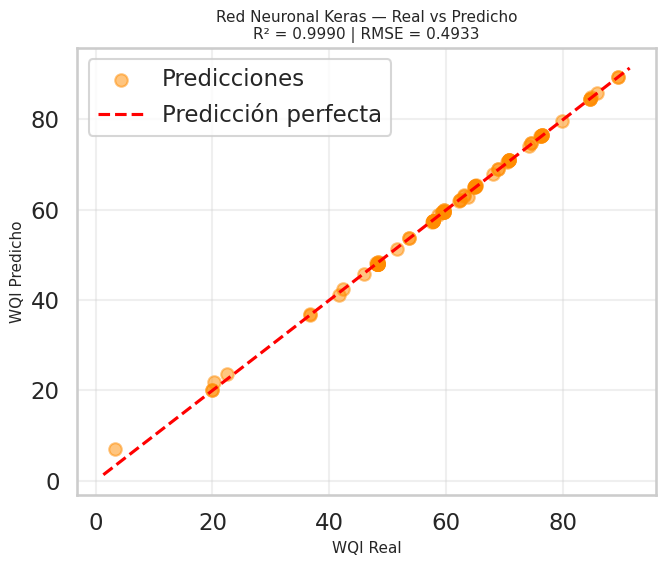

In [89]:
# ── Gráfica: Real vs Predicho (Keras) ──
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_flat, y_pred_test_k, alpha=0.5, color='darkorange', label='Predicciones')
lims = [min(y_test_flat.min(), y_pred_test_k.min()) - 2,
        max(y_test_flat.max(), y_pred_test_k.max()) + 2]
ax.plot(lims, lims, 'r--', label='Predicción perfecta')
ax.set_xlabel('WQI Real', fontsize=11)
ax.set_ylabel('WQI Predicho', fontsize=11)
ax.set_title(f'Red Neuronal Keras — Real vs Predicho\nR² = {r2_test_k:.4f} | RMSE = {rmse_test_k:.4f}', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## **11. Comparativa de Modelos**

Se comparan ambos modelos en las mismas métricas sobre el conjunto de prueba.


In [90]:
# ── Tabla comparativa ──
import pandas as pd

comparativa = pd.DataFrame({
    'Modelo'  : ['Regresión Lineal (MLlib)', 'Red Neuronal (Keras)'],
    'R²'      : [round(r2_test_lr, 4),  round(r2_test_k, 4)],
    'MAE'     : [round(mae_test_lr, 4), round(mae_test_k, 4)],
    'MSE'     : [round(mse_test_lr, 4), round(mse_test_k, 4)],
    'RMSE'    : [round(rmse_test_lr, 4),round(rmse_test_k, 4)],
})

print('\n== COMPARATIVA DE MODELOS — Conjunto de Prueba ==')
print(comparativa.to_string(index=False))
print('\nR² más cercano a 1.0 y RMSE/MAE más bajos = mejor modelo.')



== COMPARATIVA DE MODELOS — Conjunto de Prueba ==
                  Modelo    R²    MAE    MSE   RMSE
Regresión Lineal (MLlib) 1.000 0.0203 0.0052 0.0724
    Red Neuronal (Keras) 0.999 0.2461 0.2434 0.4933

R² más cercano a 1.0 y RMSE/MAE más bajos = mejor modelo.


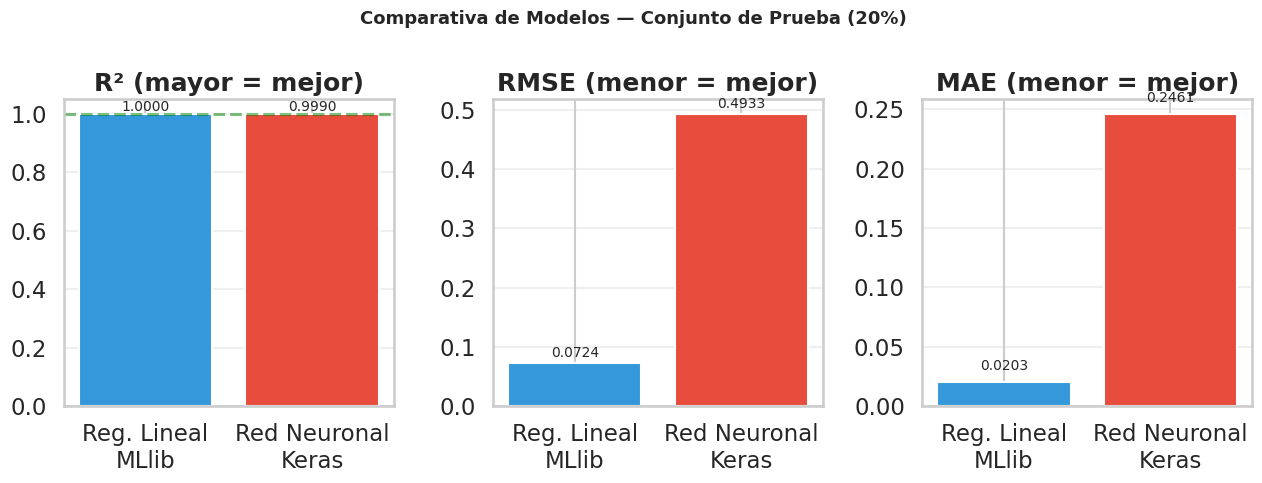

In [91]:
# ── Gráfica comparativa de métricas ──
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
modelos = ['Reg. Lineal\nMLlib', 'Red Neuronal\nKeras']
colors  = ['#3498db', '#e74c3c']

# R²
axes[0].bar(modelos, [r2_test_lr, r2_test_k], color=colors, edgecolor='white')
axes[0].set_title('R² (mayor = mejor)', fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].axhline(y=1.0, linestyle='--', color='green', alpha=0.5)
for i, v in enumerate([r2_test_lr, r2_test_k]):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# RMSE
axes[1].bar(modelos, [rmse_test_lr, rmse_test_k], color=colors, edgecolor='white')
axes[1].set_title('RMSE (menor = mejor)', fontweight='bold')
for i, v in enumerate([rmse_test_lr, rmse_test_k]):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# MAE
axes[2].bar(modelos, [mae_test_lr, mae_test_k], color=colors, edgecolor='white')
axes[2].set_title('MAE (menor = mejor)', fontweight='bold')
for i, v in enumerate([mae_test_lr, mae_test_k]):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)
axes[2].grid(axis='y', alpha=0.3)

fig.suptitle('Comparativa de Modelos — Conjunto de Prueba (20%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## **12. Cierre de Sesión Spark**


In [92]:
# Liberar recursos de la sesión Spark
sparkS.stop()
print('Sesión Spark cerrada correctamente.')


Sesión Spark cerrada correctamente.


## **13. Conclusiones**

1. **Preprocesamiento:** El dataset de calidad del agua de la India no presenta valores nulos en las variables de análisis, lo que simplificó la etapa de limpieza. Sin embargo, la heterogeneidad de las estaciones de monitoreo implica que los promedios pueden enmascarar variaciones locales importantes.

2. **WQI como variable objetivo:** Al ser el WQI una combinación lineal determinista de los rangos de calidad `qrᵢ` con pesos fijos, los modelos de ML aprenden una función matemática conocida. Esto explica por qué se esperan valores de R² muy altos en ambos modelos.

3. **Regresión Lineal (MLlib):** Modelo simple e interpretable. Los coeficientes aprendidos deben aproximarse a los pesos bibliográficos (DO≈0.281, Fecal≈0.281, COND≈0.234, etc.). Es la línea base ideal para este problema dado su carácter lineal.

4. **Red Neuronal Keras:** La arquitectura MLP de 3 capas ocultas con 350 neuronas cada una es considerablemente sobredimensionada para un dataset de esta escala. Si bien puede lograr métricas similares o superiores en entrenamiento, presenta mayor riesgo de sobreajuste. La curva de validación permite identificar si esto ocurre.

5. **Comparativa:** Para problemas con relaciones lineales subyacentes y datasets pequeños, la Regresión Lineal suele ser preferible por su menor complejidad, mayor interpretabilidad y menor tiempo de entrenamiento. La red neuronal agrega valor principalmente cuando existen interacciones no lineales entre las variables que el modelo lineal no puede capturar.

6. **Visualización geográfica:** El mapa WQI sobre los estados de la India permite identificar patrones regionales y priorizar intervenciones de política hídrica, añadiendo una dimensión analítica que va más allá de las métricas numéricas.

---
**Autor:** Juan Santiago Méndez  
**Referencia:** IntechOpen Chapter 69568 — Water Quality Index methodology  
